## Non linear regression
### K-NN Regression: averageRating

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [3]:
train_df = pd.read_csv('../results/train_clean.csv', index_col=0)
test_df = pd.read_csv('../results/test_clean.csv', index_col=0)
train_df.columns


Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'ratingNum', 'numGenres',
       'criticReviewsRatio', 'awardsAndNominations', 'hasVideos',
       'moreCountriesOfOrigin'],
      dtype='object')

In [4]:
train_df['logRuntime'] = np.log(train_df['runtimeMinutes'] + 1)
test_df['logRuntime'] = np.log(test_df['runtimeMinutes'] + 1)

In [5]:
num_cols = ['startYear', 'logRuntime', 'numVotes', 'totalImages', 'totalCredits', 'numRegions', 'numGenres', 'criticReviewsRatio']
train_X = train_df[num_cols]
test_X = test_df[num_cols]

In [6]:
train_y = pd.read_csv('../data/dm1_2425_imdb_rating/train_reg.csv')['averageRating']
test_y = pd.read_csv('../data/dm1_2425_imdb_rating/test_reg.csv')['averageRating']

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

In [8]:
splitter = KFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
%%time

ks= np.arange(1, 50, 1)
param_grid = {
    "regressor__n_neighbors": ks,
    "regressor__weights": ["uniform", "distance"],
    "regressor__metric": ["euclidean", "cityblock"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=splitter,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
    verbose=2,
    refit=True
)

grid.fit(train_X, train_y)

Fitting 5 folds for each of 196 candidates, totalling 980 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regress

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'regressor__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=2)

In [10]:
results = pd.DataFrame(grid.cv_results_)
results['metric and weight'] = results['param_regressor__metric'] + ' ' + results['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

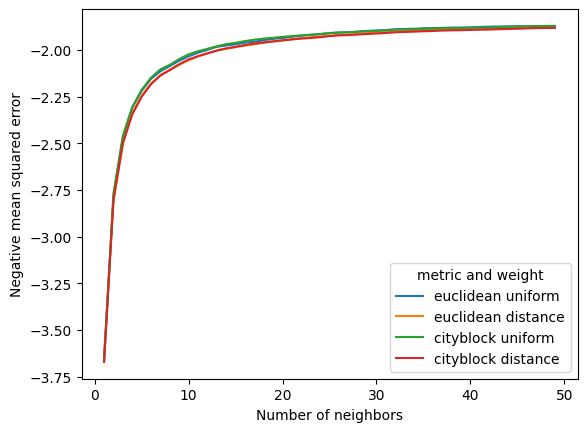

In [11]:
sns.lineplot(
    data=results,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)
plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

We can see that the model is not sensible to any of the parameters. Performance is slowly getting better the more neighbors we consider and the more the model prediction is approximating the mean rating of the whole dataset.
There's no point in refining the model selection process.

In [12]:
grid.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(49),
 'regressor__weights': 'uniform'}

In [13]:
regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

regressor.fit(train_X, train_y)
y_pred = regressor.predict(test_X)

The defaults are good enough for this.

In [14]:
print("Mean squared error:", mean_squared_error(y_true=test_y, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y, y_pred=y_pred))

Mean squared error: 2.20078882803943
R2 score: -0.20119707694332356


Text(0, 0.5, 'Real average rating')

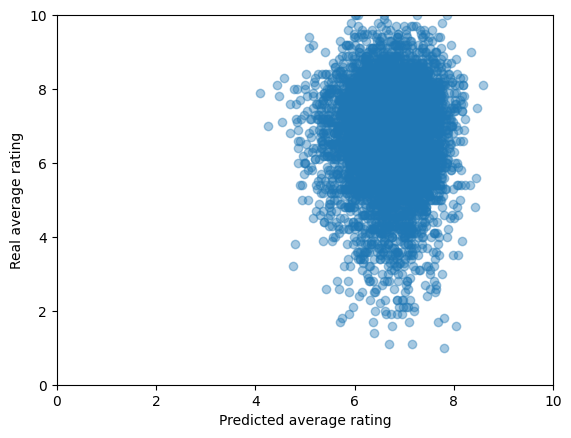

In [15]:
plt.scatter(y_pred, test_y, alpha=.4)
plt.xlim((0, 10))
plt.ylim((0, 10))
plt.xlabel("Predicted average rating")
plt.ylabel("Real average rating")

We cannot see any positive correlation between the real ratings and the predicted ratings.

We can observe that the predicted values are squeezed towards the mean rating of the entire dataset because of the strategy that the regressor uses for predicting the value (mean value of the 5 nearest neighbour). The negative R2 score means that this models performs worse than predicting the mean.

## K-NN Regression: numVotes

In [16]:
target = 'numVotes'
input_cols = num_cols.copy()
input_cols.remove(target)

In [17]:
train_X_nv, train_y_nv = train_df[input_cols], train_df[target]
test_X_nv, test_y_nv = test_df[input_cols], test_df[target]

In [18]:
%%time

ks= np.arange(1, 500, 5)
param_grid = {
    "regressor__n_neighbors": ks,
    "regressor__weights": ["uniform", "distance"],
    "regressor__metric": ["euclidean", "cityblock"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=splitter,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
    verbose=2,
    refit=True
)

grid.fit(train_X_nv, train_y_nv)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regress

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([  1,   6,  11,  16,  21,  26,  31,  36,  41,  46,  51,  56,  61,
        66,  71,  76,  81,  86,  91,  96, 101, 106, 111, 116, 121, 126,
       131, 136, 141, 1...176, 181, 186, 191,
       196, 201, 206, 211, 216, 221, 226, 231, 236, 241, 246, 251, 256,
       261, 266, 271, 276, 281, 286, 291, 296, 301, 306, 311, 316, 321,
       326, 331, 336, 341, 346, 351, 356, 361, 366, 371, 376, 381, 386,
       391, 396, 401, 406, 411, 416, 421, 426, 431, 436, 441, 446, 451,
       456, 461, 466, 471, 476, 481, 486, 491, 496]),
                         'regressor__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=2)

In [19]:
results = pd.DataFrame(grid.cv_results_)
results['metric and weight'] = results['param_regressor__metric'] + ' ' + results['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

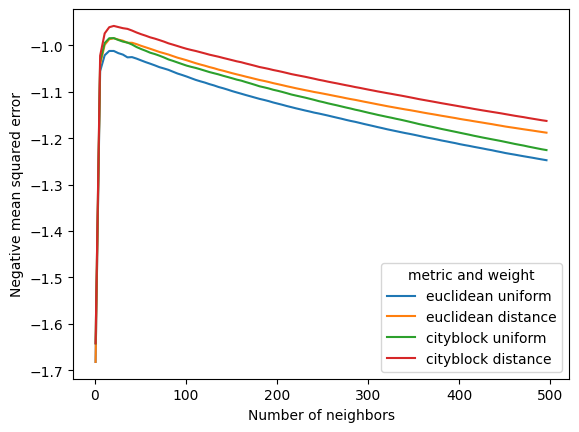

In [20]:
sns.lineplot(
    data=results,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)
plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

In [21]:
grid.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(21),
 'regressor__weights': 'distance'}

Looks like the best k would be around 20 and the best distance measure would be cityblock and we sould weight the neighbors by distance. We refine the parameters search using values of k between 1 and 50.

We can also see that the mean squared error for this task is much lower than that for the previous task.

In [28]:
param_grid['regressor__n_neighbors'] = np.arange(1, 50)
grid_mini = GridSearchCV(pipeline,
                         param_grid=param_grid,
                         verbose=2,
                         n_jobs=-1)
grid_mini.fit(train_X_nv, train_y_nv)

Fitting 5 folds for each of 196 candidates, totalling 980 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regresso

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'regressor__weights': ['uniform', 'distance']},
             verbose=2)

In [29]:
results_mini = pd.DataFrame(grid_mini.cv_results_)
results_mini['metric and weight'] = results_mini['param_regressor__metric'] + ' ' + results_mini['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

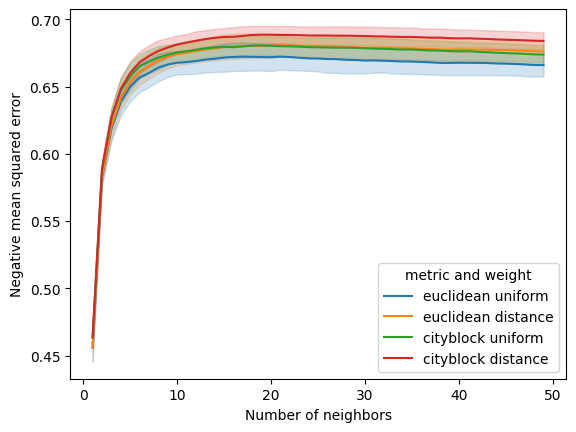

In [30]:
ax = sns.lineplot(
    data=results_mini,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)

handles, labels = ax.get_legend_handles_labels()
colors = {
    label: handle.get_color()
    for label, handle in zip(labels, handles)
}

for i, (label, df) in enumerate(results_mini.groupby('metric and weight')):
    x = df['param_regressor__n_neighbors'].astype('int')
    mean_score = df['mean_test_score']
    std_score = df['std_test_score']

    ax.fill_between(
        x=x, y1=mean_score + std_score, y2=mean_score - std_score,
        alpha=.2, color=colors[label]
    )

plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

In [31]:
grid_mini.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(19),
 'regressor__weights': 'distance'}

In [34]:
y_pred = grid.predict(test_X_nv)

In [35]:
print("Mean squared error:", mean_squared_error(y_true=test_y_nv, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y_nv, y_pred=y_pred))

Mean squared error: 0.9646055119317702
R2 score: 0.6869466526088873


Text(0, 0.5, 'Predicted numVotes')

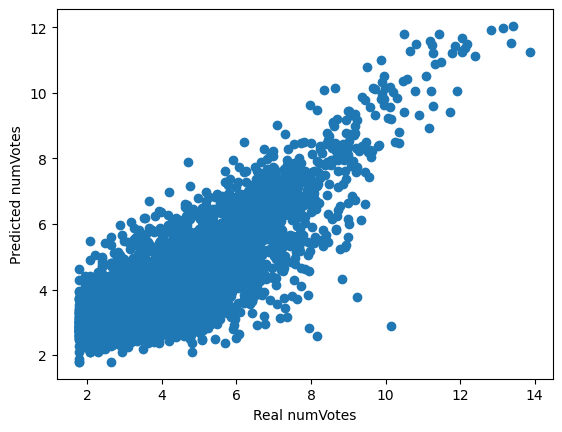

In [37]:
plt.scatter(test_y_nv, y_pred)
plt.xlabel("Real numVotes")
plt.ylabel("Predicted numVotes")

In [46]:
np.corrcoef(y_pred,
            test_y_nv)

array([[1.        , 0.82903853],
       [0.82903853, 1.        ]])

We can see that the model is much better in this task. The mean squared error in much lower, we have a positive and high determination coefficient and the prediceted and real values are highly and positively correlated (Pearson 0.83), as can also be seen by the scatter plot.